In [1]:
import json
import os
import urllib

def download_and_load_file(file_path, url):
    if not os.path.exists(file_path):
        with urllib.request.urlopen(url) as response:
            text_data = response.read().decode("utf-8")
        with open(file_path, "w", encoding="utf-8") as f:
            f.write(text_data)

    with open(file_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    return data

file_path = "../data/instruction-data.json"
url = "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/main/ch07/01_main-chapter-code/instruction-data.json"

data = download_and_load_file(file_path, url)
print(f"Number of entries: {len(data)}")

def format_input(entry, prompt_style="alpaca"):
    if prompt_style == "alpaca":
        instruction_text = (
            f"Below is an instruction that describes a task. "
            f"Write a response that appropriately completes the request."
            f"\n\n### Instruction:\n{entry['instruction']}"
        )

        input_text = (
            f"\n\n### Input:\n{entry['input']}" if entry['input'] else ""
        )

        return instruction_text + input_text
    elif prompt_style == "phi-3":
        punc = entry['instruction'][-1]
        user_request = f"<|user|>\n{entry['instruction'][:-1]}"
        if entry['input']:
            user_request += f": {entry['input']}"
        else:
            user_request += punc
        return user_request
    else:
        raise ValueError(f"'{prompt_style}' is not a recognized prompt style.")
    
def full_instruction_prompt_tokenize(entry, tokenizer, prompt_style="alpaca"):
    model_input_tokenized = tokenizer.encode(format_input(entry, prompt_style))
    if prompt_style == "alpaca":
        desired_response = f"\n\n### Response:\n{entry['output']}"
    elif prompt_style == "phi-3":
        desired_response = f"\n\n<|assistant|>\n{entry['output']}"
    else:
        raise ValueError(f"'{prompt_style}' is not a recognized prompt style.")
    return model_input_tokenized, tokenizer.encode(desired_response)

train_portion = int(len(data) * 0.85)
test_portion = int(len(data) * 0.1)
val_portion = len(data) - train_portion - test_portion

train_data = data[:train_portion]
test_data = data[train_portion:train_portion + test_portion]
val_data = data[train_portion+test_portion:]

print(f"Training set length: {len(train_data)}")
print(f"Validation set length: {len(val_data)}")
print(f"Test set length: {len(test_data)}")

Number of entries: 1100
Training set length: 935
Validation set length: 55
Test set length: 110


In [2]:
import torch
from torch.utils.data import Dataset

class InstructionDataset(Dataset):
    def __init__(self, data, tokenizer, prompt_style="alpaca"):
        self.data = data
        self.encoded_texts = []
        for entry in data:
            self.encoded_texts.append(full_instruction_prompt_tokenize(entry, tokenizer, prompt_style))

    def __getitem__(self, index):
        return self.encoded_texts[index]

    def __len__(self):
        return len(self.data)
    
import tiktoken
tokenizer = tiktoken.get_encoding("gpt2")

def custom_collate_fn(batch, pad_token_id=50256,
                      ignore_index=-100,
                      allowed_max_length=None,
                      device="cpu",
                      mask_instructions=False):
    batch_max_length = max(len(item[0] + item[1]) for item in batch) + 1
    inputs_lst, targets_lst = list(), list()

    for item in batch:
        instruction_length = len(item[0])
        new_item = item[0].copy() + item[1].copy()
        new_item += [pad_token_id]
        padded = new_item + [pad_token_id] * (batch_max_length - len(new_item))

        inputs = torch.tensor(padded[:-1])
        targets = torch.tensor(padded[1:])

        mask = targets == pad_token_id
        indices = torch.nonzero(mask).squeeze()
        if indices.numel() > 1:
            targets[indices[1:]] = ignore_index

        if mask_instructions:
            targets[:instruction_length-1] = ignore_index
        
        # Set to the context length of the model
        if allowed_max_length is not None:
            inputs = inputs[:allowed_max_length]
            targets = targets[:allowed_max_length]

        inputs_lst.append(inputs)
        targets_lst.append(targets)
    
    inputs_tensor = torch.stack(inputs_lst).to(device)
    targets_tensor = torch.stack(targets_lst).to(device)
    return inputs_tensor, targets_tensor

In [3]:
from functools import partial

device = torch.device("cuda")

customized_collate_fn = partial(custom_collate_fn,
    device=device,
    allowed_max_length=1024)

instruction_masking_collate_fn = partial(custom_collate_fn,
    device=device,
    allowed_max_length=1024,
    mask_instructions=True)

In [4]:
from gpt_download import download_and_load_gpt2
from gpt_modules import GPTModel
from weight_loader import load_weights_into_gpt

2025-12-05 21:01:46.749118: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-12-05 21:01:46.749213: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-12-05 21:01:46.764421: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-12-05 21:01:46.795032: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-05 21:01:49.336465: W tensorflow/compiler/tf2

In [5]:
BASE_CONFIG = {
    "vocab_size": 50_257,
    "context_length": 1024,
    "drop_rate": 0.0,
    "qkv_bias": True
}

model_configs = {
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16}
}

CHOOSE_MODEL = "gpt2-medium (355M)"
BASE_CONFIG.update(model_configs[CHOOSE_MODEL])
model_size = CHOOSE_MODEL.split(" ")[-1].lstrip("(").rstrip(")")

settings, params = download_and_load_gpt2(
    model_size = model_size,
    models_dir="gpt2"
)

checkpoint: 100%|██████████| 77.0/77.0 [00:00<00:00, 149kiB/s]
encoder.json: 100%|██████████| 1.04M/1.04M [00:00<00:00, 1.28MiB/s]
hparams.json: 100%|██████████| 91.0/91.0 [00:00<00:00, 163kiB/s]
model.ckpt.data-00000-of-00001: 100%|██████████| 1.42G/1.42G [03:14<00:00, 7.31MiB/s] 
model.ckpt.index: 100%|██████████| 10.4k/10.4k [00:00<00:00, 22.1MiB/s]
model.ckpt.meta: 100%|██████████| 927k/927k [00:00<00:00, 1.39MiB/s]
vocab.bpe: 100%|██████████| 456k/456k [00:00<00:00, 676kiB/s] 


In [6]:
from functools import partial
from torch.utils.data import DataLoader
from gpt_training_utils import generate, text_to_token_ids, token_ids_to_text, calc_loss_loader, train_model_with_bells_and_whistles

instruction_masking_collate_fn = partial(custom_collate_fn,
    device=device,
    allowed_max_length=1024,
    mask_instructions=True)

num_workers = 0
batch_size = 32

torch.manual_seed(123)

train_dataset = InstructionDataset(train_data, tokenizer)
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    collate_fn=instruction_masking_collate_fn,
    shuffle=True,
    drop_last=True,
    num_workers=num_workers
)

val_dataset = InstructionDataset(val_data, tokenizer)
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    collate_fn=instruction_masking_collate_fn,
    shuffle=False,
    drop_last=False,
    num_workers=num_workers
)

test_dataset = InstructionDataset(test_data, tokenizer)
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    collate_fn=instruction_masking_collate_fn,
    shuffle=False,
    drop_last=False,
    num_workers=num_workers
)

In [7]:
import math
import torch
from torch.nn import Module

class LoRALayer(Module):
    def __init__(self, in_dim, out_dim, rank, alpha):
        super(LoRALayer, self).__init__()
        self.A = torch.nn.Parameter(torch.empty(in_dim, rank))
        torch.nn.init.kaiming_uniform_(self.A, a=math.sqrt(5)) 
        self.B = torch.nn.Parameter(torch.zeros(rank, out_dim)) # Initialize as zero, so LoRA starts as AB=0
        self.alpha = alpha # Scaling factor

    def forward(self, x):
        x = self.alpha * (x @ self.A @ self.B)
        return x
    
class LinearWithLoRA(Module):
    def __init__(self, linear, rank, alpha):
        super(LinearWithLoRA, self).__init__()
        self.linear = linear
        self.lora = LoRALayer(in_dim=linear.in_features,
                              out_dim=linear.out_features,
                              rank=rank,
                              alpha=alpha)
        
    def forward(self, x):
        linear_out = self.linear(x) # x @ W (Original weights)
        lora_out = self.lora(x) # x @ AB
        return linear_out + lora_out # x @ W + x @ AB = x @ (W + AB)
    
def replace_linear_with_lora_(model, rank, alpha, verbose=False): # Added "_" to the end, because works in-place
    for name, module in model.named_children():
        if isinstance(module, torch.nn.Linear):
            setattr(model, name, LinearWithLoRA(module, rank, alpha))
            if verbose:
                print(f"{name} has been changed to LinearWithLoRA")
        else:
            replace_linear_with_lora_(module, rank, alpha)

In [8]:
model = GPTModel(BASE_CONFIG)
load_weights_into_gpt(model, params)


In [9]:
for param in model.parameters():
    param.requires_grad = False

replace_linear_with_lora_(model, rank=16, alpha=16)

In [10]:
model.to(device)

torch.manual_seed(123)

with torch.no_grad():
    train_loss = calc_loss_loader(
        train_loader, model, device, num_batches=5
    )
    val_loss = calc_loss_loader(
        val_loader, model, device, num_batches=5
    )

print(f"Training Loss: {train_loss}")
print(f"Validation Loss: {val_loss}")

Training Loss: 2.331354284286499
Validation Loss: 2.3047133684158325


In [11]:
import time
start_time = time.time()
torch.manual_seed(123)
optimizer = torch.optim.AdamW(
    model.parameters(), lr=1e-4, weight_decay=0.1
)
num_epochs=3
warmup_steps = int(0.2 * len(train_loader) * num_epochs)

train_losses, val_losses, track_tokens_seen, track_lrs = train_model_with_bells_and_whistles(
    model,
    train_loader,
    val_loader,
    optimizer,
    device,
    num_epochs,
    eval_freq=5,
    eval_iter=1,
    start_context=format_input(val_data[0]),
    tokenizer=tokenizer,
    warmup_steps=warmup_steps,
    initial_lr=1e-5,
    min_lr=1e-5,
)

end_time = time.time()
execution_time_mins = (end_time - start_time) / 60
print(f"Training completed in {execution_time_mins:.2f} minutes.")

Ep 1 (Iter 000000):  Train loss 1.654,  Val loss 1.654
Ep 1 (Iter 000005):  Train loss 1.038,  Val loss 1.138
Ep 1 (Iter 000010):  Train loss 0.828,  Val loss 1.105
Ep 1 (Iter 000015):  Train loss 0.771,  Val loss 1.037
Ep 1 (Iter 000020):  Train loss 0.813,  Val loss 1.019
Ep 1 (Iter 000025):  Train loss 0.735,  Val loss 1.070
Below is an instruction that describes a task. Write a response that appropriately completes the request.  ### Instruction: Convert the active sentence to passive: 'The chef cooks the meal every day.'  ### Response: The chef cooks the meal every day.<|endoftext|>The first thing you see when you walk into the room is the ceiling.  The second thing you see is the ceiling. The third thing you see is the ceiling
Ep 2 (Iter 000030):  Train loss 0.863,  Val loss 1.079
Ep 2 (Iter 000035):  Train loss 0.599,  Val loss 1.049
Ep 2 (Iter 000040):  Train loss 0.640,  Val loss 1.018
Ep 2 (Iter 000045):  Train loss 0.604,  Val loss 1.004
Ep 2 (Iter 000050):  Train loss 0.597,

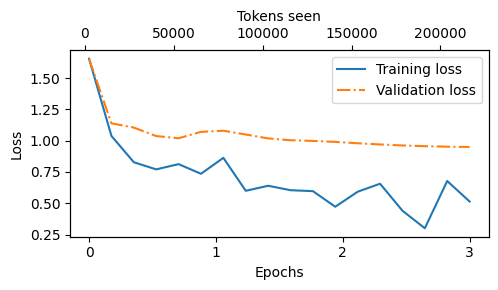

In [12]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator


def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(5, 3))
    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(epochs_seen, val_losses, linestyle="-.", label="Validation loss")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))

    ax2 = ax1.twiny()
    ax2.plot(tokens_seen, train_losses, alpha=0)
    ax2.set_xlabel("Tokens seen")
    fig.tight_layout()
    plt.show()


epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, track_tokens_seen, train_losses, val_losses)

In [13]:
from tqdm import tqdm

for i, entry in tqdm(enumerate(test_data), total=len(test_data)):
    input_text = format_input(entry)

    token_ids = generate(
        model=model,
        idx=text_to_token_ids(input_text, tokenizer).to(device),
        max_new_tokens=256,
        context_size = BASE_CONFIG["context_length"],
        eos_id=50256
    )

    generated_text = token_ids_to_text(token_ids, tokenizer)
    response_text = generated_text[len(input_text):].replace("### Response:", "").strip()
    test_data[i]["model_response"] = response_text

with open("instruction-data-with-response-lora.json", "w") as f:
    json.dump(test_data, f, indent=4)

100%|██████████| 110/110 [01:06<00:00,  1.65it/s]


### Results

Combining these results with what we had in Chapter 7, we see that while LoRA show similar training characteristics it overfits more and underperforms in the test set according to Haiku 4.5.

This table has been calculated using LLM-as-a-judge evaluation technique, where a Claude Haiku 4.5 model was asked to score the responses between 0 and 100:

| Method                                            | Score (0 - 100) &#8593;  | Training Time &#8595; |
| ------------------------------------------------- | ------------------------ | --------------------- |
| Alpaca-Style Prompts - Instruction Loss Included  | 34.05                    | 0.72 Minutes          |
| Alpaca-Style Prompts - Instruction Loss Ignored   | **38.99**                | 0.70 Minutes          |
| Phi-3 Style Prompts - Instruction Loss Included   | 33.95                    | 0.59 Minutes          |
| Phi-3 Style Prompts - Instruction Loss Ignored    | 34.97                    | **0.58 Minutes**      |
| LoRA - Alpaca-Style Prompts - Instruction Loss Ignored  | 24.11              | 0.67 Minutes   |

In this experiment, we observe that ignoring the loss on instruction tokens increase the scores in both instruction styles. Additionally, we observed that Alpaca-style prompts performed better than the Phi-3 style prompts in both cases. Though, because I did not do early stopping or any kind of hyperparameter tuning, this should be taken with a grain of salt.
  
Furthermore, we see that the training time of the Phi-3 style prompts is less than of the Alpaca style ones. I assume this is due to the created sequence length, as the computation time should be lower for shorter sequences.

Last but not least, we see that LoRA has similar training characteristics to other methods, but its performance in the test set is not satisfactory. Something to note is, in GPT-2 Medium, we see that the added inference cost of LoRA is negated.